In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
project_root = Path.cwd().resolve().parents[2]
sys.path.append(str(project_root))

from defs.vae.ae import *
from defs.vae.training_defs import *
from defs.training_defs.loss import *
wavelengths = [str(w) for w in range(400, 2491, 10)]

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

spectra, fractions = load_spectral_data()
train_loader, val_loader = get_dataloaders(spectra, fractions, batch_size=1)
num_spectra = train_loader.dataset[0][0].size(0)
print(train_loader.batch_size)
print(num_spectra)

Device: cpu
1
210


In [4]:
convolution = VCCAE([train_loader.batch_size, 64, 64], [256, 256], c_d={'pad': 1}, num_spectra=num_spectra)

ratio = 1 # Coefficient of spectral angle mapper (SAM) loss
sam_criterion = loss_mse_sam(ratio=ratio)

def criterion(estimated, actual, mu, variation):
    pred_loss = nn.functional.mse_loss(estimated, actual[0])
    divergence = -0.5 * torch.sum(1 + variation - mu.pow(2) - variation.exp()) # Kullback-Leibler
    sam_loss = sam_criterion.calc(estimated, actual)
    return pred_loss + divergence + sam_loss

learning_rate = 1e-3
optimizer = optim.Adam(convolution.parameters(), lr=learning_rate)

n_epochs = 4

In [5]:
train_losses = []
val_losses = []

for epoch in range(1, n_epochs+1):
    # Training loop
    convolution.train()
    tot_loss = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        estimated, mu, variation = convolution(xb, yb)
        optimizer.zero_grad()
        loss_pred = criterion(estimated, xb, mu, variation)
        loss_pred.backward()
        optimizer.step()

        tot_loss += float(loss_pred)

    train_losses.append(tot_loss / len(train_loader.dataset))

    convolution.eval()
    tot_val = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            estimated, mu, variation = convolution(xb, yb)
            tot_val += criterion(estimated, xb, mu, variation).item() * xb.size(0)
    val_losses.append(tot_val / len(val_loader.dataset))

    print(f'Epoch {epoch}, loss: {tot_val/len(val_loader.dataset)}')

/Users/galacticmilk/Desktop/Michael's folder/[UNI]/[UTAT]/[science]/FINCH-Science_SyntheticData/defs/training_defs/loss.py:29: UserWarning: Using a target size (torch.Size([210])) that is different to the input size (torch.Size([1, 210])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_mse = F.mse_loss(x0_hat, x0)


Epoch 1, loss: 1.340198184614596
Epoch 2, loss: 1.2389222347218058
Epoch 3, loss: 1.2447576022666433
Epoch 4, loss: 1.2827773850897084


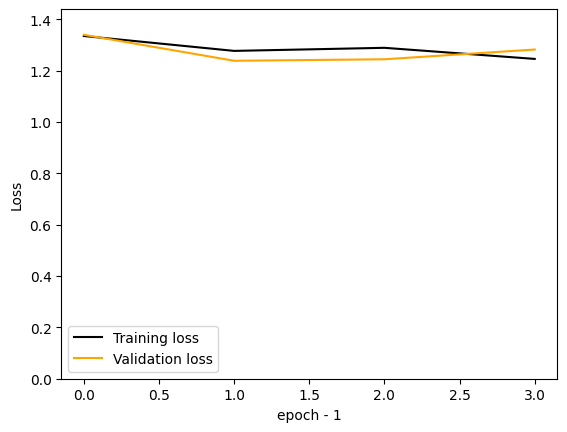

In [6]:
plt.plot(train_losses, color='black', label='Training loss')
plt.plot(val_losses, color='orange', label='Validation loss')
plt.ylim(0, max(max(train_losses), max(val_losses)) + 0.1)
plt.xlabel('epoch - 1'); plt.ylabel('Loss'); plt.legend()

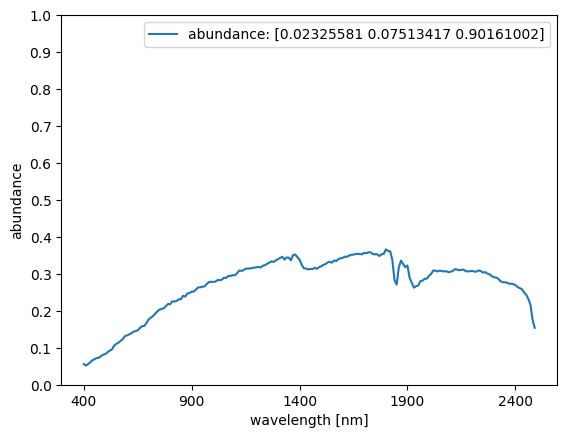

In [ ]:
# Random spectrum generator! (Adopted from test.ipynb file)
rand_noise = torch.Tensor(np.random.random(3)) # 1d array
tot_abundance = 1
a = tot_abundance/np.random.randint(1, 100)
tot_abundance -= a
b = tot_abundance/np.random.randint(1, 100)
c = tot_abundance - b
abundance = [a, b, c]
adjusted = convolution.conditioner(rand_noise, torch.Tensor(abundance))
produced_spectrum = convolution.decoder(adjusted)
produced_spectrum = produced_spectrum.detach().numpy()
rand_noise = np.asarray(rand_noise)
# print(rand_noise)
# print(produced_spectrum)
joined = np.concatenate((rand_noise, abundance, produced_spectrum))

# file.write(f'{joined[0]}')
# for i in joined[1:]:
#     file.write(f',{i}')
# file.write(f'\n')
plt.plot(wavelengths, produced_spectrum, label=f'abundance: {np.asarray(abundance)}')
plt.ylim(0, 1)
plt.xticks([i for i in range(0, 250, 50)])
plt.yticks([i/10 for i in range(0, 11)])
plt.legend()
plt.xlabel(f'wavelength [nm]')
plt.ylabel(f'abundance')
plt.show()